This scripts executes the difference in differences analysis for Cosy

In [1]:
# Function to check if a package is installed, and if not, install it
install_if_needed <- function(package) {
  if (!require(package, character.only = TRUE)) {
    install.packages(package, dependencies = TRUE)
    library(package, character.only = TRUE)
  }
}

# List of packages to load
packages <- c(
  "knitr", "kableExtra", "did", "fixest", "data.table", "lubridate", 
  "dplyr", "ggplot2", "RColorBrewer", "tidyr", "scales", 
  "forcats", "viridis", "stringr"
)

# Load (and install if needed) each package
lapply(packages, install_if_needed)

# set dictionary
setFixest_dict(c(total_consumption = "Consumption in kWh per period", 
                 daily_consumption = "Consumption in kWh per day",
                 consumption_hh = "Half Hourly Consumption in kWh",
                 share_consumption = "Share of daily consumption",
                 weekly_consumption = "Gas Consumption per Week in kWh",
                 cosy_contract_active = "Cosy Contract Active",
                 daily_avg_heating_degree = "HDD",
                 avg_heating_degree = "HDD",
                 settlement_week = "Week",
                 date = "Day", 
                 hashed_mpan = "Household", 
                 tariff_gsp_group_id = "GSP", 
                 rate_period = "Rate period",
                 is_variable = "Variable Tariff",
                 energy_efficiency = "Energy Efficiency",
                 estimated_annual_consumption = "EAC",
                 eac_mwh = "EAC in mWh",
                 is_hp_installed = "Is HP Installed",
                 predicted_is_installed = "Is HP Installed",
                 elec_consumption = "Monthly Electricity Consumption (kWh)",
                 gas_consumption = "Monthly Gas Consumption (kWh)",
                 month_date = "Month",
                 is_winter = "Winter",
                 previous_is_variable = "Prev Is Variable",
                 epc_letter = "EPC",
                 predicted_heatloss_watts = "Heatloss (W)",
                 total_floor_area = "Floor Area (m sq)",
                 urban = "Urban",
                 floor_area = "Floor area",
                 property_value = "Property value",
                 account_id = "Household",
                 ev_charging = "EV Charging",
                 has_ev = "EV User"))


# Custom colors from the provided image 
flexible_color <- "#4C515C"  # Replace with the exact hex code for Flexible
cosy_color <- "#5F8ED9"      # Replace with the exact hex code for Cosy


Loading required package: knitr

Loading required package: kableExtra

Loading required package: did

Loading required package: fixest

Loading required package: data.table

Loading required package: lubridate


Attaching package: ‘lubridate’


The following objects are masked from ‘package:data.table’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:kableExtra’:

    group_rows


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: RColorBrewer

Loading required package: tidyr

Loading r

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

[[5]]
NULL

[[6]]
NULL

[[7]]
NULL

[[8]]
NULL

[[9]]
NULL

[[10]]
NULL

[[11]]
NULL

[[12]]
NULL

[[13]]
NULL

[[14]]
NULL

## Load data

In [2]:

if(!file.exists("../data/scratch/aggregated_data.RDS")) {
  
  # agreement data
  agreements <- fread("../data/input/Cosy_-_agreement_data_2024_07_24.csv") %>%
    filter(product_display_name == "Cosy Octopus") %>%
    arrange(hashed_mpan, agreement_valid_from) %>%
    mutate(
      from = as.Date(agreement_valid_from),
      to = as.Date(agreement_valid_to)
    ) %>%
    select(hashed_mpan, from, to) %>%
    group_by(hashed_mpan) %>%
    summarise(
      periods = list(data.frame(from, to)),
      first_adoption = min(from),  # Get the earliest agreement date for 'adoption'
      first_week = format(min(from), "%Y-%U"),  # Format the first adoption date as year-week
      .groups = 'drop'
    )
  
  aggregated_data <- rbind(fread("../data/input/cosy_-_cosy_electricity_reading_part_2_2024_07_26.csv"),
                           fread("../data/input/cosy_-_cosy_electricity_reading_part_2_2024_07_26 (1).csv"),
                           fread("../data/input/cosy_-_cosy_electricity_reading_part_2_2024_07_26 (2).csv")) %>%
    rename(total_consumption = total_read_value,
           consumption_hh = mean_read_value) %>%
    mutate(date = as.Date(settlement_date)) %>% 
    filter(!is.na(date))     %>%
    select(-c(settlement_date))
  
  # Function to check if a date falls within any period
  check_active_contract <- function(date, periods) {
    any(sapply(1:nrow(periods[[1]]), function(i) date >= periods[[1]][i, "from"] && (date <= periods[[1]][i, "to"] | is.na(periods[[1]][i, "to"]))))
  }
  
  # Add indicator without heavy merging
  consumption_with_indicator <- aggregated_data %>%
    rowwise() %>%
    mutate(
      cosy_contract_active = {
        periods <- agreements$periods[agreements$hashed_mpan == hashed_mpan]
        if (length(periods) == 0) 0 else as.integer(check_active_contract(date, periods))
      }
    ) %>%
    ungroup()
  
  # join with the earliest adoption date
  aggregated_data <- consumption_with_indicator %>%
    inner_join(agreements %>% select(-periods))
  
  # add overall
  aggregated_data <- rbind(
    aggregated_data, 
    aggregated_data %>% 
      group_by(account_id, hashed_mpan, date, cosy_contract_active, first_adoption, first_week) %>%
      summarise(total_consumption = sum(total_consumption)) %>%
      mutate(rate_period = "Overall",
             consumption_hh = total_consumption/48)) %>%
    mutate(rate_period = factor(rate_period, levels = c("Morning Cosy",
                                                        "Afternoon Cosy",
                                                        "Peak Rate",
                                                        "Other", 
                                                        "Overall")), 
           weeks_since_cosy = floor(as.numeric(difftime(date, first_adoption, units = "weeks")))) 
  
  # Remove the ~ 50 mpans with 2 account id
  duplicate_mpan <- aggregated_data %>%
    select(account_id, hashed_mpan) %>%    # Selecting the necessary columns
    distinct() %>%                         # Removing completely identical rows
    count(hashed_mpan) %>%                 # Count occurrences of each hashed_mpan
    filter(n > 1) %>%                      # Keep only those with more than one occurrence
    left_join(aggregated_data %>% group_by(account_id, hashed_mpan) %>% summarise(min_date = min(date), max_date = max(date)), by = "hashed_mpan") %>%
    arrange(hashed_mpan, account_id)       # Arrange for better visibility
  
  # add customers characteristics
  cosy_cosy_details_2024_06_25 <- fread("../data/input/cosy_-_cosy_details_2024_06_25.csv") %>%
    distinct()
  
  # Remove moan associated with two accounts !
  merged_data <- aggregated_data %>%
    filter(!hashed_mpan %in% duplicate_mpan$hashed_mpan) %>%
    inner_join(cosy_cosy_details_2024_06_25)
  
  # add weather
  weather <- fread("../data/input/Cosy Analysis Weather Mar 26 daily.csv") %>% 
    rename_with(.cols = starts_with("weekly"), 
                .fn = ~ sub("^weekly", "daily", .)) %>%
    mutate(date_day=as.Date(date_day, format = "%Y-%m-%d")) %>%
    rename(date = date_day)
  
  aggregated_data <- merged_data %>%
    left_join(weather, by =c("gsp_group_id", "date"))
  
  
  Prev_contract <- fread("../data/input/Cosy_-_agreement_data_2024_07_24.csv") %>%
    arrange(hashed_mpan, as.Date(agreement_valid_from)) %>%
    group_by(hashed_mpan) %>%
    mutate(
      previous_contract = lag(product_display_name),
      previous_is_variable = lag(is_variable),
      previous_is_charged_half_hourly = lag(is_charged_half_hourly),
      is_cosy = product_display_name == "Cosy Octopus"
    ) %>%
    filter(is_cosy) %>%
    slice_head(n=1)
  
  
  aggregated_data <- aggregated_data %>%
    mutate(epc_letter = case_when(
      energy_efficiency >= 91 ~ "A",
      energy_efficiency >= 81 & energy_efficiency <= 90 ~ "B",
      energy_efficiency >= 69 & energy_efficiency <= 80 ~ "C",
      energy_efficiency >= 55 & energy_efficiency <= 68 ~ "D",
      energy_efficiency >= 39 & energy_efficiency <= 54 ~ "E",
      energy_efficiency >= 21 & energy_efficiency <= 38 ~ "F",
      energy_efficiency <= 20 ~ "G",
      TRUE ~ NA_character_
    ),
    eac_mwh = estimated_annual_consumption/1000) %>%
    left_join(Prev_contract)
  
  
  saveRDS(aggregated_data, "../data/scratch/aggregated_data.RDS")
  
  rm(weather, adoption, consumption_with_indicator, agreements)
} else {
  aggregated_data <- readRDS("../data/scratch/aggregated_data.RDS") 
  
}


# Unique periods 
periods <- unique(aggregated_data$rate_period)

# Define base periods
base_periods <- c("varying", "universal")

start_date <- min(floor_date(aggregated_data$date, "week"))

In [ ]:

### this exact same code is actually ran on the jupyter notebook, it takes too long on laptop
for (period in periods) {
  for (base_period in base_periods) {
    
    # Determine the filename based on the base period
    file_suffix <- ifelse(base_period == "universal", "_universal", "")
    filename <- paste0("../data/scratch/did_cosy_", period, file_suffix, ".RDS")
    
    # Check if the file already exists
    if (!file.exists(filename)) {
      
      # Adjust your existing code to calculate 'week' and 'firstweek' as the number of weeks from the start_date
      did_data <- aggregated_data %>%
        ungroup() %>%
        filter(rate_period == period, !hashed_mpan == "1185945433") %>% # exclude this odd mpan because it only has others periods
        mutate(settlement_week = floor_date(date, "week"),
               week = difftime(settlement_week, start_date, units = "weeks"),
               firstweek =  difftime(floor_date(first_adoption, "week"), start_date, units = "weeks")) %>%
        group_by(hashed_mpan, firstweek, week) %>%
        summarise(consumption_hh = mean(consumption_hh)) %>%
        mutate(
          firstweek = as.numeric(firstweek),
          week = as.numeric(week)
        ) %>% group_by(hashed_mpan) %>%
        mutate(id = cur_group_id()) %>%
        ungroup()
      
      # Estimating the treatment effect using the Callaway and Sant'Anna method
      est_cs <- att_gt(yname = "consumption_hh",
                       tname = "week",
                       idname = "id",
                       gname = "firstweek",
                       data = did_data,
                       clustervars = "id",
                       anticipation = 1,
                       control_group = "notyettreated",
                       allow_unbalanced_panel = TRUE,
                       base_period = base_period,
                       cores = 10)
      
      # Save the result
      saveRDS(est_cs, filename)
    }
  }
}

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1210237,64.7,2517341,134.5,1985937,106.1
Vcells,679600676,5185.0,867782585,6620.7,679701030,5185.8


`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.
Warning message in att_gt(yname = "consumption_hh", tname = "week", idname = "id", :
“Not returning pre-test Wald statistic due to singular covariance matrix”
`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.
Warning message in att_gt(yname = "consumption_hh", tname = "week", idname = "id", :
“Not returning pre-test Wald statistic due to singular covariance matrix”
`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.
Warning message in att_gt(yname = "consumption_hh", tname = "week", idname = "id", :
“Not returning pre-test Wald statistic due to singular covariance matrix”
`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.


## CS DiD

In [7]:
# Unique periods 
for(period in periods) {
  
  # Load CS
  est_cs <- readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS"))
  
  # create the graphs
  est_cs$first_week <- (weeks(est_cs$group -1) + floor_date(start_date, "week"))
  est_cs$week <- (floor_date(start_date, "week") + weeks(est_cs$t-1))
  p <- data.frame(group = est_cs$group,
                  se = est_cs$se,
                  t = est_cs$t, date = est_cs$week, att = est_cs$att, first_week = est_cs$first_week)
  
  p <- p %>%
    filter(first_week<= date) 
  
  # Plot with a gradient color scale
  ggplot(p, aes(x = date, y = att, color = first_week, group = first_week)) +
    geom_ribbon(aes(ymin = att - se, ymax = att + se), fill = "grey80", alpha = 0.5, color=NA) +  # Shaded area for standard error
    geom_line() +
    geom_point() +
    scale_x_date(
      labels = scales::date_format("%b %y"),  # Formatting months and years
      date_breaks = "3 month"  # Adjust this based on your data density
    ) +
    labs(
      x = "Calendar Time",
      y = "Average ATT",
      color = "Adoption Week"
    ) +
    scale_color_gradientn(colors = c("lightblue", "blue", "darkblue"),
                          breaks = as.Date(seq(19337, 19885, 100)),
                          labels = format(format(as.Date(seq(19337, 19885, 100)), "%b %Y"))) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),  # Tilt x-axis labels for better readability
      legend.position = "right"  # Position the legend on the right
    )
  ggsave(paste0("../graphs/monthly_att_", period %>% tolower() %>% str_replace(" ", "_"), ".png"))
  
}

Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


### Figure 9: Cosy Dynamic ATTs

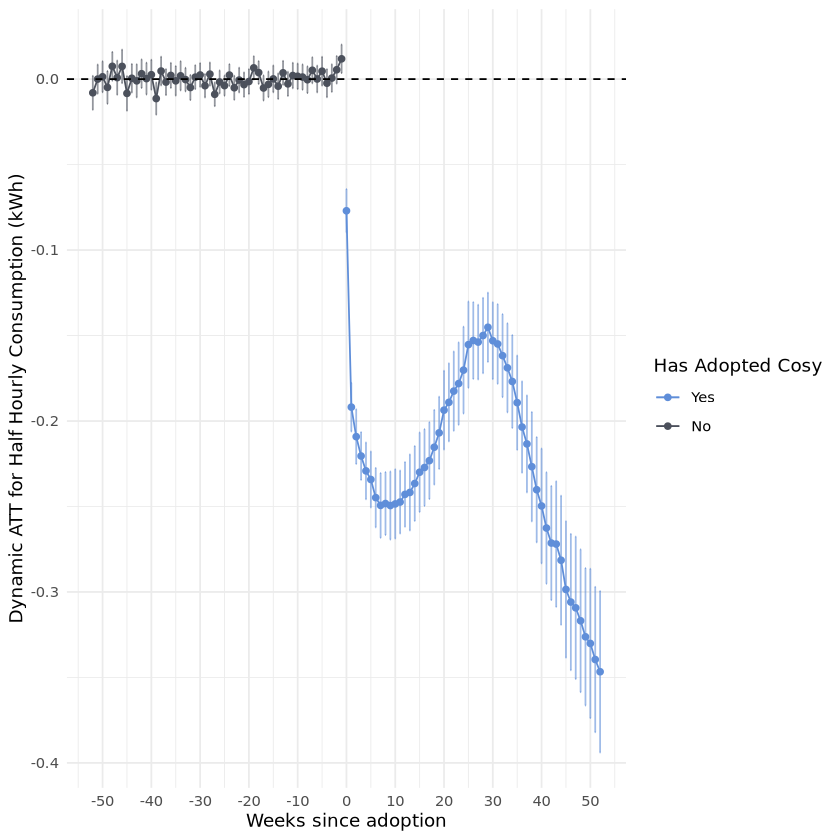

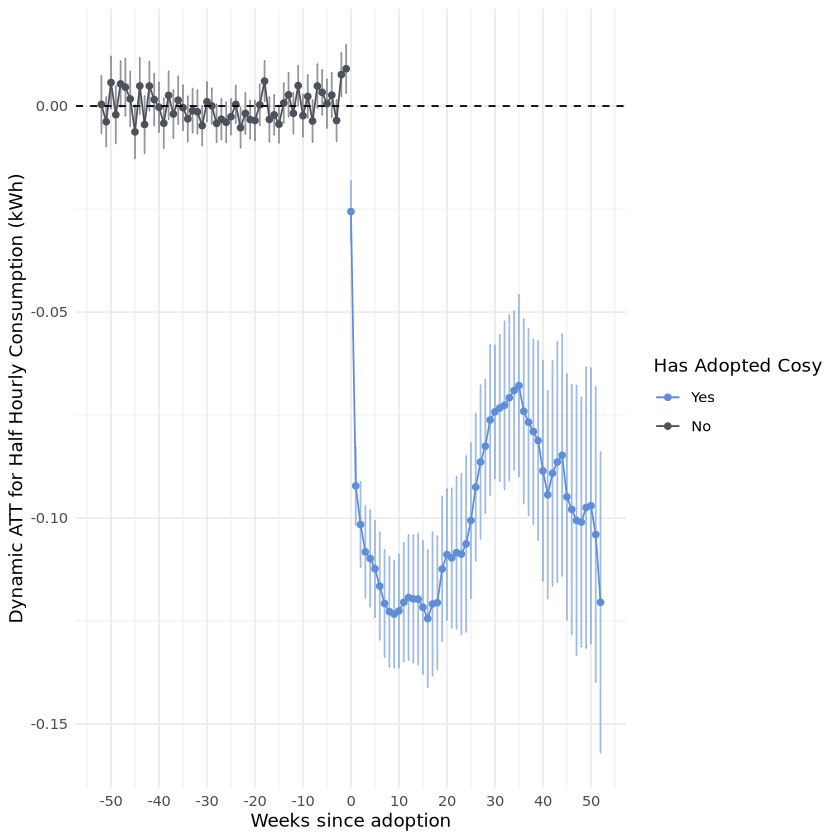

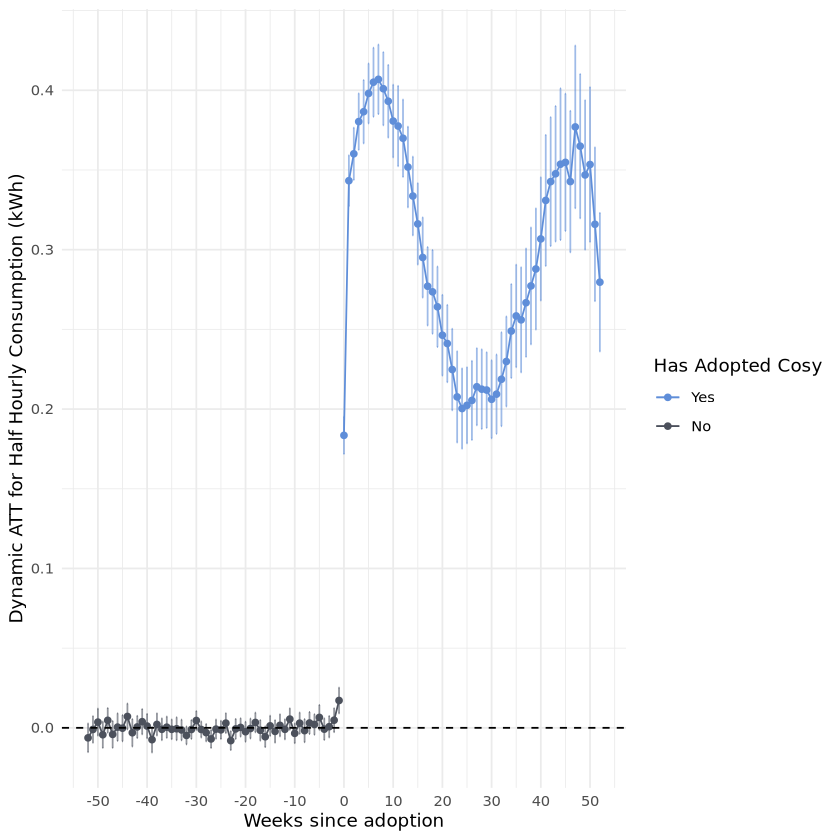

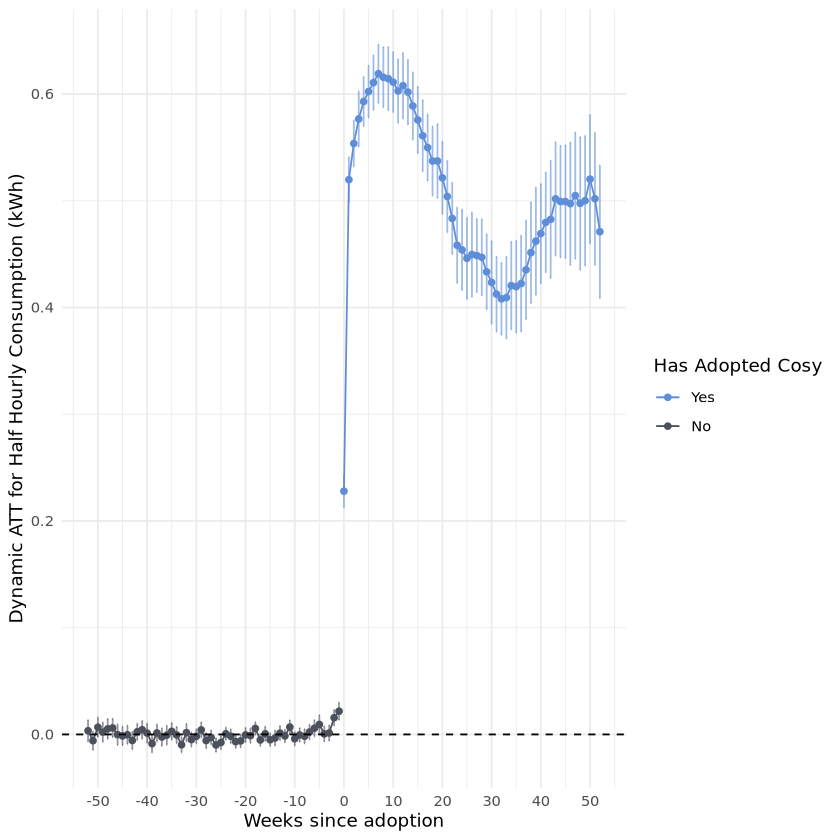

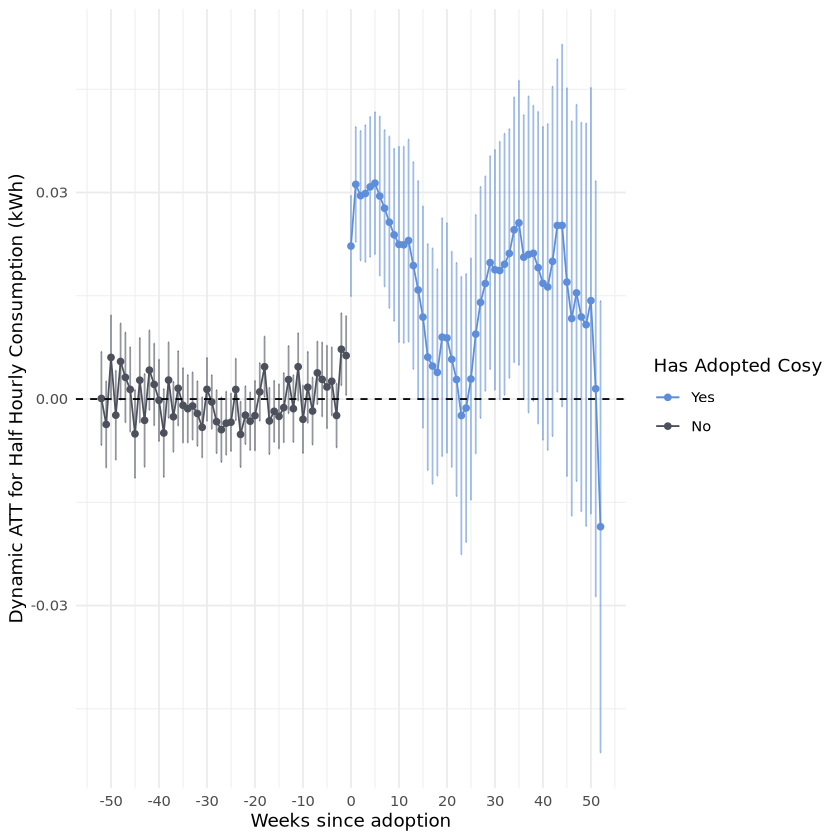

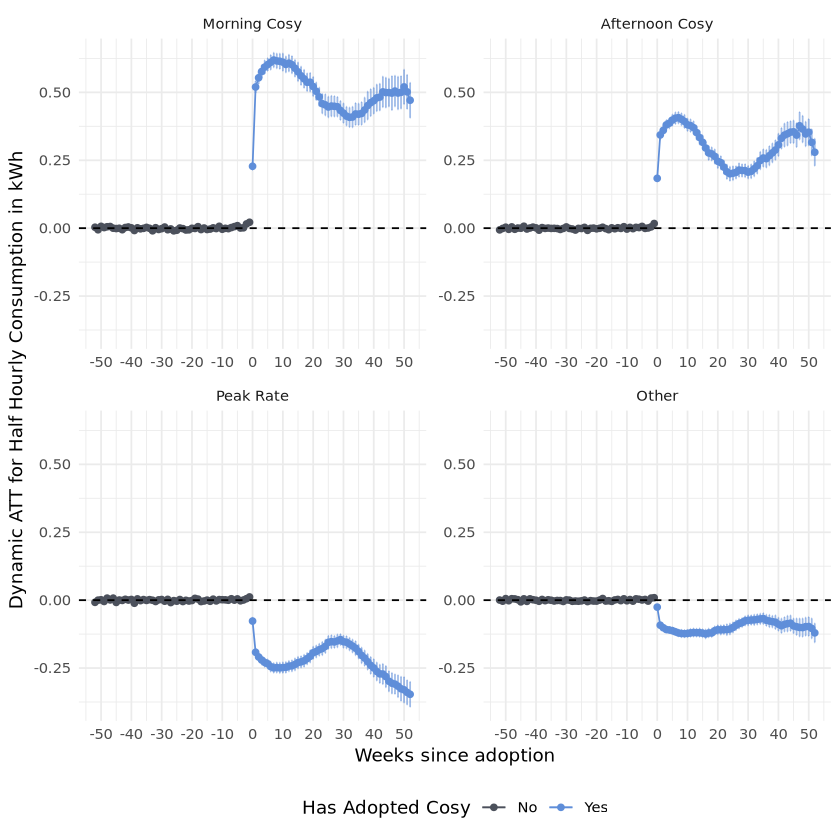

In [8]:
# Function to create the ggplot for each period
create_ggplot <- function(period_data, period_name) {
  # Extract coefficients, standard errors, and event time
  coefficients <- period_data$att.egt   # Convert to daily values
  standard_errors <- period_data$se.egt   # Convert to daily values
  event_time <- period_data$egt
  
  # Create a data frame for plotting
  plot_data <- data.frame(
    event_time = event_time,
    coefficient = coefficients,
    lower_ci = coefficients - 1.96 * standard_errors,
    upper_ci = coefficients + 1.96 * standard_errors,
    period = ifelse(event_time < 0, "No", "Yes")
  )
  
  # Reverse the color order
  plot_data$period <- factor(plot_data$period, levels = c("Yes", "No"))
  
  # Create the ggplot
  p <- ggplot(plot_data, aes(x = event_time, y = coefficient, color = period)) +
    geom_point() +
    geom_line() +
    geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, , alpha = 0.6) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
    scale_color_manual(
      name = "Has Adopted Cosy", 
      labels = c("No" = "No", "Yes" = "Yes"),
      values = c("No" = flexible_color, "Yes" = cosy_color)  # Custom colors
    ) +
    scale_x_continuous(breaks = seq(-50, 50, 10)) +
    labs(
      x = "Weeks since adoption",
      y = "Dynamic ATT for Half Hourly Consumption (kWh)"
    ) +
    theme_minimal()
  
  return(p)
}

# Loop through each period and create/save the plots
for(period in periods) {
  
  # Load CS
  est_cs <- readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS"))
  
  # Retrieve estimates
  period_data <- aggte(est_cs, type="dynamic",alp = 0.01, min_e = -52, max_e = 52)
  
  # Create the plot
  p <- create_ggplot(period_data, period)
  
  # Print the plot
  print(p)
  
  # Define the filename
  file_name <- paste("../graphs/plot_", period, ".png", sep = "")
  
  # Save the plot
  ggsave(file_name, plot = p, device = "png", width = 10, height = 8, dpi = 300)
}

# Function to create the data frame for each period
create_dynamic_data <- function(period_data, period_name) {
  # Extract coefficients, standard errors, and event time
  coefficients <- period_data$att.egt
  standard_errors <- period_data$se.egt
  event_time <- period_data$egt
  
  # Create a data frame for plotting
  plot_data <- data.frame(
    event_time = event_time,
    coefficient = coefficients,
    lower_ci = coefficients - 1.96 * standard_errors,
    upper_ci = coefficients + 1.96 * standard_errors,
    period = period_name,
    cosy_status = ifelse(event_time < 0, "No", "Yes")
  )
  
  return(plot_data)
}

# Initialize an empty data frame to store all period data
start_date <- min(aggregated_data$date)
all_period_data <- data.frame()

# Loop through each period to create the combined data frame
for(period in periods) {
  # Load CS
  est_cs <- readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS"))
  
  # Retrieve estimates
  period_data <- aggte(est_cs, type = "dynamic", alp = 0.01, min_e = -52, max_e = 52)
  
  # Create the data frame for the current period
  period_plot_data <- create_dynamic_data(period_data, period)
  
  # Combine the data
  all_period_data <- bind_rows(all_period_data, period_plot_data)
}

all_period_data <- all_period_data %>% 
  filter(!period=="Overall") %>%
  mutate(period = factor(period, levels = c("Morning Cosy",
                                            "Afternoon Cosy",
                                            "Peak Rate",
                                            "Other", 
                                            "Overall")))

# Define global y-axis limits
y_min <- min(all_period_data$lower_ci)
y_max <- max(all_period_data$upper_ci)

# Create the ggplot for all periods using facet_wrap
ggplot(all_period_data, aes(x = event_time, y = coefficient, color = cosy_status)) +
  geom_point() +
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
  scale_color_manual(
    name = "Has Adopted Cosy", 
    labels = c("No" = "No", "Yes" = "Yes"),
    values = c("No" = flexible_color, "Yes" = cosy_color)  # Adjust these colors as needed
  ) +
  scale_x_continuous(breaks = scales::pretty_breaks(n = 10)) +
  scale_y_continuous(limits = c(y_min, y_max)) +  # Set consistent y-axis range
  labs(
    x = "Weeks since adoption",
    y = "Dynamic ATT for Half Hourly Consumption in kWh"
  ) +
  theme_minimal() +
  theme(legend.position="bottom") +
  facet_wrap(~ period, scales = "free")



# Save the combined plot
ggsave("../graphs/dynamic_att_combined.png",  device = "png", width = 16, height = 12, dpi = 300)



### Figure 10: Cosy Electricity Calendar ATTs

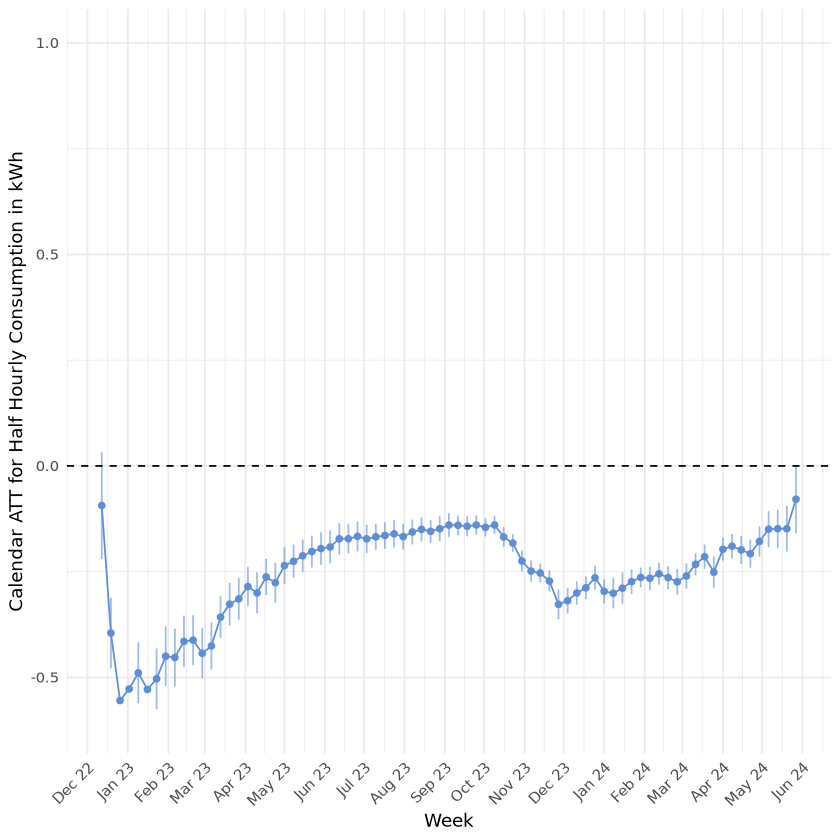

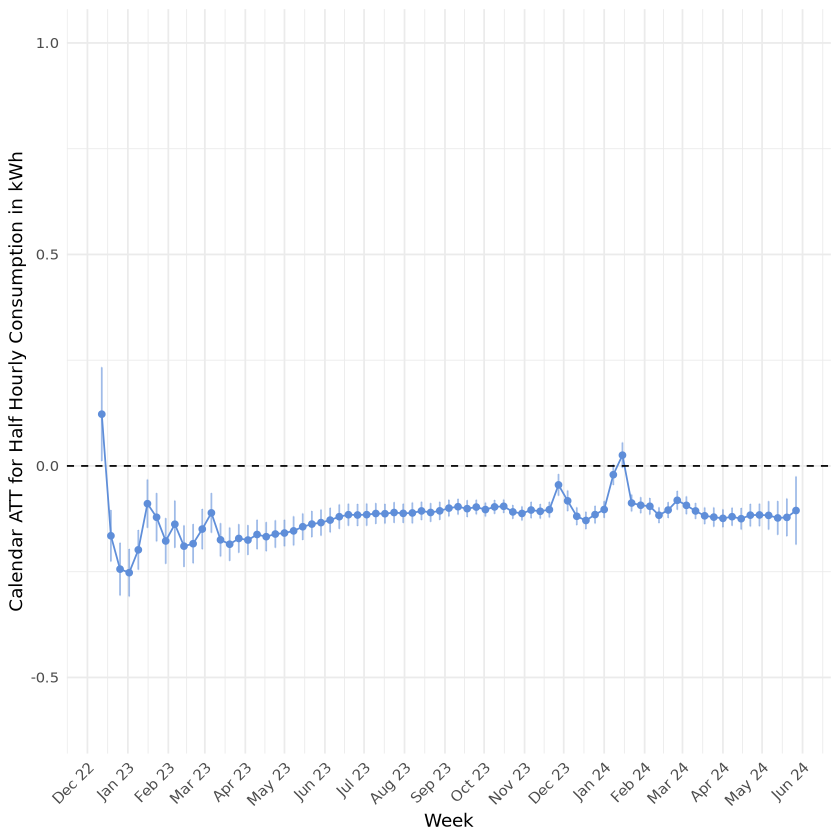

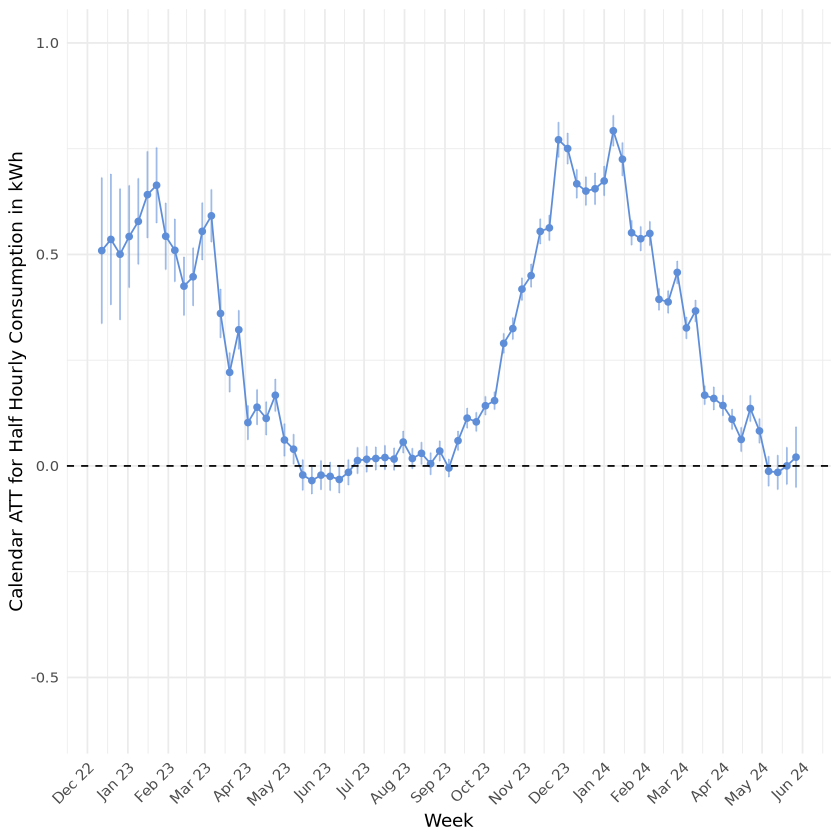

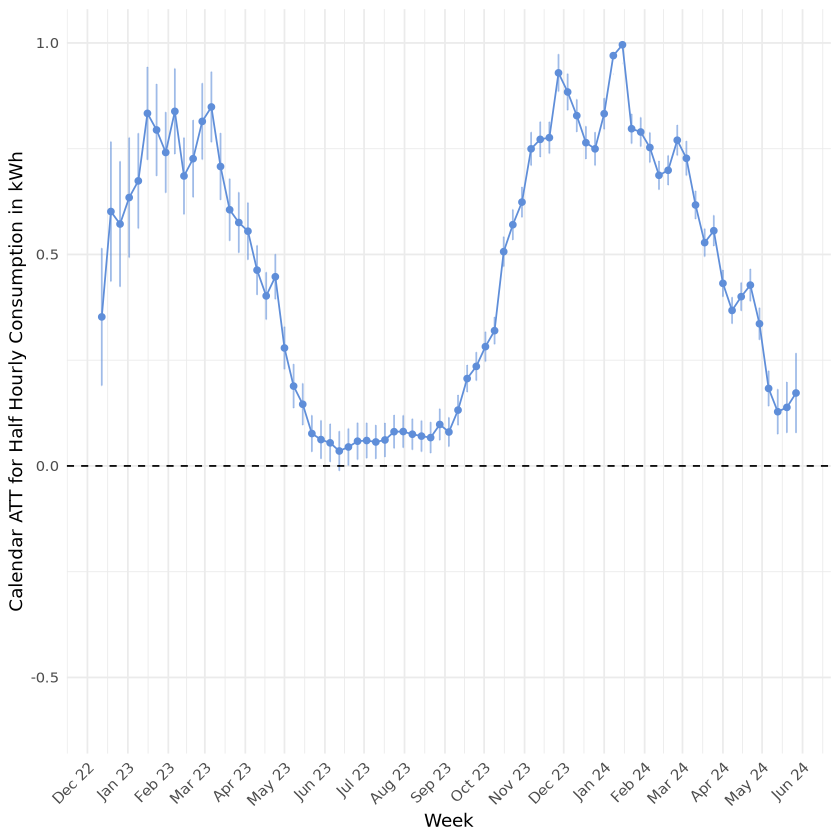

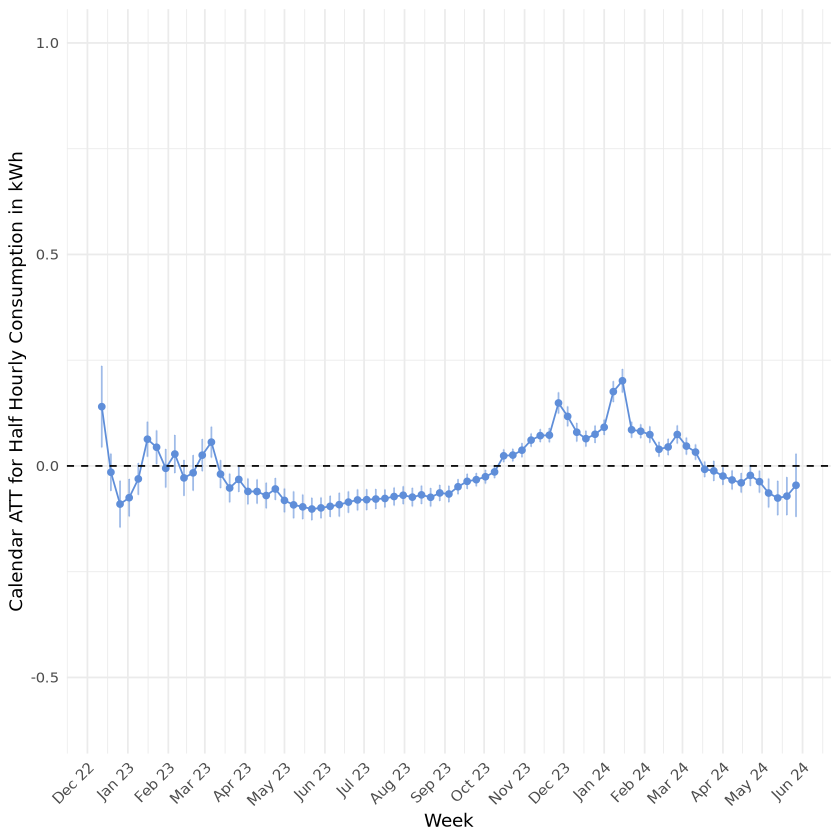

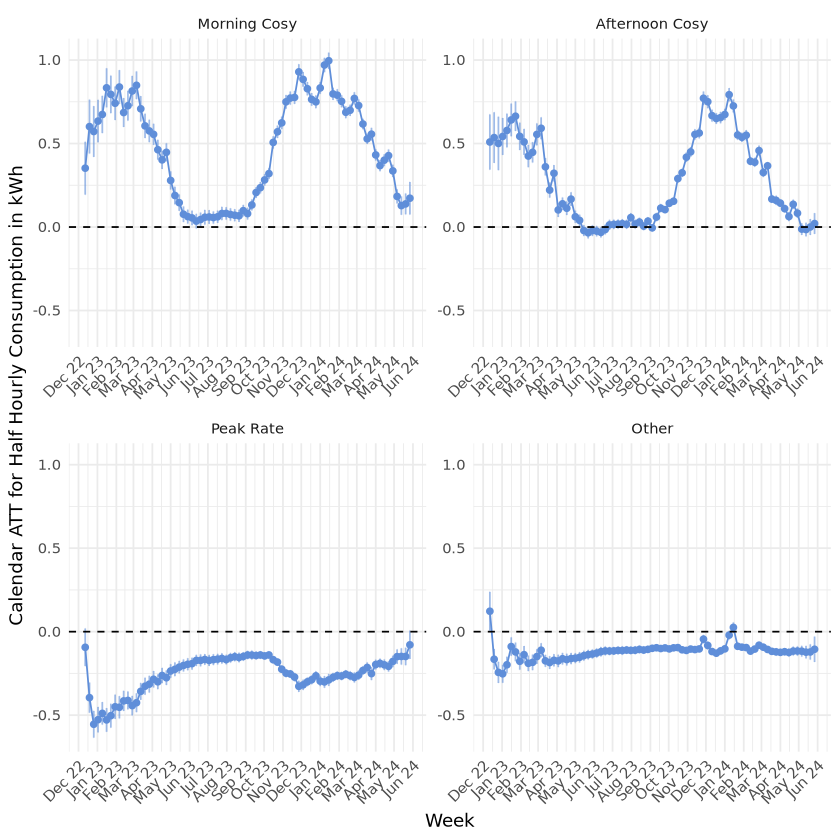

In [9]:


# Function to create the ggplot for each period
create_calendar_ggplot <- function(period_data, period_name, start_date, y_min, y_max) {
  # Extract estimates, standard errors, and egt (event time)
  estimates <- period_data$att.egt   # Convert to daily values
  standard_errors <- period_data$se.egt   # Convert to daily values
  event_time <- period_data$egt
  
  # Calculate the week dates based on the start_date
  week_dates <- start_date + weeks(event_time)
  
  # Create a data frame for plotting
  plot_data <- data.frame(
    week_date = week_dates,
    estimate = estimates,
    lower_ci = estimates - 1.96 * standard_errors,
    upper_ci = estimates + 1.96 * standard_errors
  )
  
  
  # Create the ggplot for calendar effect
  p <- ggplot(plot_data, aes(x = week_date, y = estimate)) +
    geom_point(color = cosy_color) +
    geom_line(color = cosy_color) +
    geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, color = cosy_color, alpha = 0.6) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
    scale_x_date(
      labels = scales::date_format("%b %y"),  # Formatting months and years
      date_breaks = "1 month"  # Adjust this based on your data density
    ) +    
    scale_y_continuous(limits = c(y_min, y_max)) +  # Set consistent y-axis range
    labs(
      x = "Week",
      y = "Calendar ATT for Half Hourly Consumption in kWh"
    ) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate x-axis labels for better readability
  
  return(p)
}

# # Find the global y-axis limits
# all_estimates <- unlist(lapply(estimates_list, function(period) period$calendar$att.egt ))
# all_standard_errors <- unlist(lapply(estimates_list, function(period) period$calendar$se.egt ))
# all_lower_ci <- all_estimates - 1.96 * all_standard_errors
# all_upper_ci <- all_estimates + 1.96 * all_standard_errors
# 
# y_min <- min(all_lower_ci)
# y_max <- max(all_upper_ci)

# Loop through each period and create/save the plots
for(period in periods) {
  
  # Load CS
  est_cs <- readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS"))
  
  # Retrieve estimates
  period_data <- aggte(est_cs, type="calendar",alp = 0.01)
  
  # Create the plot
  p <- create_calendar_ggplot(period_data, period, start_date, -0.6, 1)
  
  # Print the plot
  print(p)
  
  # Define the filename
  file_name <- paste("../graphs/calendarplot_", period, ".png", sep = "")
  
  # Save the plot
  ggsave(file_name, plot = p, device = "png", width = 5, height = 4, dpi = 300)
}

# 
# y_min <- -5
# y_max <- 5
# 
# # Loop through each period and create/save the calendar effect plots
# for (period in c("Peak Rate", "Afternoon Cosy")) {
#   period_data <- estimates_list[[period]]$calendar
#   
#   # Create the plot
#   p <- create_calendar_ggplot(period_data, period, start_date, y_min, y_max)
#   
#   # Print the plot
#   print(p)
#   
#   # Define the filename
#   file_name <- paste("../graphs/calendarplot_", period, ".png", sep = "")
#   
#   # Save the plot
#   ggsave(file_name, plot = p, device = "png", width = 5, height = 4, dpi = 300)
# }


# Function to create the data frame for each period
create_calendar_data <- function(period_data, period_name, start_date) {
  # Extract estimates, standard errors, and egt (event time)
  estimates <- period_data$att.egt   # Convert to daily values
  standard_errors <- period_data$se.egt   # Convert to daily values
  event_time <- period_data$egt
  
  # Calculate the week dates based on the start_date
  week_dates <- start_date + weeks(event_time)
  
  # Create a data frame for plotting
  plot_data <- data.frame(
    week_date = week_dates,
    estimate = estimates,
    lower_ci = estimates - 1.96 * standard_errors,
    upper_ci = estimates + 1.96 * standard_errors,
    period = period_name
  )
  
  return(plot_data)
}

# Initialize an empty data frame to store all period data
all_period_data <- data.frame()

# Loop through each period to create the combined data frame
for(period in periods) {
  # Load CS
  est_cs <- readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS"))
  
  # Retrieve estimates
  period_data <- aggte(est_cs, type = "calendar", alp = 0.01)
  
  # Create the data frame for the current period
  period_plot_data <- create_calendar_data(period_data, period, start_date)
  
  # Combine the data
  all_period_data <- bind_rows(all_period_data, period_plot_data)
}

all_period_data <- all_period_data %>%
  filter(period != "Overall") %>%
  mutate(period = factor(period, levels = c("Morning Cosy",
                                            "Afternoon Cosy",
                                            "Peak Rate",
                                            "Other", 
                                            "Overall")))

# Define global y-axis limits (if needed)
y_min <- min(all_period_data$lower_ci)
y_max <- max(all_period_data$upper_ci)

# Create the ggplot for all periods using facet_wrap
ggplot(all_period_data, aes(x = week_date, y = estimate)) +
  geom_point(color = cosy_color) +  # Use your desired color
  geom_line(color = cosy_color) +   # Use your desired color
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, color = cosy_color, alpha = 0.6) +  # Use your desired color
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
  scale_x_date(
    labels = scales::date_format("%b %y"),  # Formatting months and years
    date_breaks = "1 month"  # Adjust this based on your data density
  ) +
  scale_y_continuous(limits = c(y_min, y_max)) +  # Set consistent y-axis range
  labs(
    x = "Week",
    y = "Calendar ATT for Half Hourly Consumption in kWh"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position="bottom") +  # Rotate x-axis labels for better readability
  facet_wrap(~ period, scales = "free")

# Save the combined plot
ggsave("../graphs/calendarplot_combined.png",  device = "png", width = 16, height = 12, dpi = 300)



In [11]:
# Function to format numbers
format_number <- function(number) {
  return(format(round(number), big.mark = ",", scientific = FALSE))
}

# Function to format numbers with four decimal places
format_decimal <- function(number, decimals = 4) {
  return(format(round(number, decimals), nsmall = decimals, big.mark = ",", scientific = FALSE))
}


# Register the pre-treatment average fit statistic
fitstat_register("pre_avg", function(x) {
  
  # Extract the formula
  formula <- x$fml_all$linear
  
  # Extract the outcome variable from the formula
  outcome_variable <- all.vars(formula)[1]
  
  # Extract the call object and evaluate the data argument
  call_object <- x$call
  data_expr <- call_object$data
  data <- eval(data_expr)
  
  # Get the logical vector of observations used in the model
  obs_used <- obs(x)
  
  # Subset the original dataset using this logical vector
  data_used <- data[obs_used, ]
  
  # Ensure the outcome variable is treated as a column name
  outcome_values <- data_used[[outcome_variable]]
  
  # Create pre-avg for non-HP installed group
  pre_avg <- mean(outcome_values[data_used$cosy_contract_active == 0], na.rm = TRUE)
  
  # Format the pre-avg
  formatted_pre_avg <- format_decimal(pre_avg)
  
  return(formatted_pre_avg)
}, "Half Hourly Consumption")



# Add number of time periods
fitstat_register("t_obs", function(x) {
  
  # time variable
  t_var <- x$fixef_vars[3]
  
  # nbr of unique val for t var
  t_obs <- x$fixef_sizes[t_var]
  
  return(format_number(t_obs))
}, "Number of Time Periods")

CleanPreAverage <- function(file_path) {
  
  # Read the generated LaTeX file
  file_content <- readLines(file_path)
  
  # Find the lines with the pre-treatment average and remove them
  if (length(grep("Half Hourly Consumption", file_content))==1) {
    pre_avg_line_index <- grep("Half Hourly Consumption", file_content)
  } else {
    pre_avg_line_index <- grep("Half Hourly Consumption", file_content)[2]
  }
  
  pre_avg_lines <- file_content[pre_avg_line_index:(pre_avg_line_index)]
  file_content <- file_content[-c(pre_avg_line_index, pre_avg_line_index)]
  
  # Find the position just after the coefficients
  coeff_end_index <- grep("Fixed-effects", file_content) -2
  
  # Insert the pre-treatment average row after the coefficients
  file_content <- append(file_content, pre_avg_lines, after = coeff_end_index)
  file_content <- append(file_content, "\\emph{Pre-Treatment Average}\\\\", after = coeff_end_index)
  
  # Add a \midrule after the pre-treatment average
  file_content <- append(file_content, "\\midrule", after = coeff_end_index)
  
  # Modify the label for "Size of the 'effective' sample" to "Number of Households"
  sample_line <- grep("Size of the 'effective' sample", file_content)
  file_content[sample_line] <- gsub("Size of the 'effective' sample", "Number of Households", file_content[sample_line])
  
  # Write the modified content back to the LaTeX file
  writeLines(file_content, file_path)
}

main_periods <- unique(aggregated_data$rate_period)


#if (!file.exists("../tables/did.tex")) {
m1 <- feols(consumption_hh ~ i(cosy_contract_active) | daily_avg_heating_degree + account_id + date, 
            data = aggregated_data, 
            cluster = ~account_id, 
            split = ~ rate_period)

etable(m1, m1, tex=TRUE, title = "Cosy Adoption",
       headers = list(list("TWFE" = 5, "CS" = 5),
                      list(rep(as.character(sort(main_periods)), times = 2))), 
       fitstat = ~ N + g + pre_avg +t_obs + r2, file = "../tables/did.tex", replace = TRUE, label="tab:did-main")

CleanPreAverage("../tables/did.tex")

In [12]:

main_periods <- unique(aggregated_data$rate_period)

# Initialize variables to store estimates and standard errors
cs_estimates <- list()
cs_se <- list()
cs_n <- list()
cs_nG <- list()
cs_nT <- list()
cs_pre_avg <- list()

# Loop through each period to get the Callaway and Sant'Anna estimates
for(period in main_periods) {
  # Load CS
  est_cs <- readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS"))
  
  # Simple Aggte
  aggte_simple <- aggte(est_cs, type = "simple", na.rm = TRUE, clustervars="id", bstrap=TRUE, alp = 0.01)
  print(aggte_simple)
  
  # Pre treatment average
  pre_treatment_average <- aggte_simple$DIDparams$data %>%
    ungroup() %>%
    filter(week < firstweek - 1) %>%
    summarise(consumption_hh = mean(consumption_hh))
  
  cs_estimates[[period]] <- aggte_simple$overall.att
  cs_se[[period]] <- aggte_simple$overall.se
  cs_n[[period]] <- format_number(aggte_simple$DIDparams$n)
  cs_nG[[period]] <- format_number(aggte_simple$DIDparams$nG)
  cs_nT[[period]] <- format_number(aggte_simple$DIDparams$nT)
  cs_pre_avg[[period]] <- format_decimal(pre_treatment_average)
}

# Define the file path
file_path <- "../tables/did.tex"

# Read the generated LaTeX file
file_content <- readLines(file_path)

# Format the estimates and standard errors to four decimal places
cs_estimates <- lapply(cs_estimates, function(x) sprintf("%.4f", x))
cs_se <- lapply(cs_se, function(x) sprintf("%.4f", x))

# Find the rows that need to be updated
coeff_line <- grep("Cosy Contract Active \\$=\\$ 1", file_content)
se_line <- coeff_line + 1
obs_line <- grep("Observations", file_content)
sample_line <- grep("Number of Households", file_content)
periods_line <- grep("Number of Time Periods", file_content)
hdd_line <- grep("HDD", file_content)
mpan_line <- grep("Household", file_content)[1]
day_line <- grep("Day", file_content)
pre_avgs <- grep("Half Hourly Consumption", file_content)[2]
r2_line <- grep("R", file_content)[-1]

# Function to replace the 6th to 10th columns in a LaTeX table row
replace_columns <- function(line, new_values) {
  parts <- strsplit(line, "&")[[1]]
  for (i in seq_along(new_values)) {
    parts[6 + i] <- str_trim(new_values[[i]])
  }
  return(paste(parts, collapse = " & "))
}

# Function to clear the 6th to 10th columns in a LaTeX table row
clear_columns <- function(line) {
  parts <- strsplit(line, "&")[[1]]
  for (i in 7:length(parts)) {
    parts[i] <- ""
  }
  return(paste(parts, collapse = " & "))
}

# Ensure each replacement maintains the LaTeX table structure
new_estimates <- c(paste0(cs_estimates[["Morning Cosy"]], "***"), 
                   paste0(cs_estimates[["Afternoon Cosy"]], "***"), 
                   paste0(cs_estimates[["Peak Rate"]], "***"), 
                   paste0(cs_estimates[["Other"]], "***"), 
                   paste0(cs_estimates[["Overall"]]))
new_se <- c(paste0("(", cs_se[["Morning Cosy"]], ")"), 
            paste0("(", cs_se[["Afternoon Cosy"]], ")"), 
            paste0("(", cs_se[["Peak Rate"]], ")"), 
            paste0("(", cs_se[["Other"]], ")"), 
            paste0("(", cs_se[["Overall"]], ")"))
file_content[sample_line] <- replace_columns(file_content[sample_line], cs_n) %>% paste0(" \\\\")
file_content[coeff_line] <- replace_columns(file_content[coeff_line], new_estimates) %>% paste0(" \\\\")
file_content[se_line] <- replace_columns(file_content[se_line], new_se) %>% paste0(" \\\\")
file_content[periods_line] <- replace_columns(file_content[periods_line], cs_nT) %>% paste0(" \\\\")
file_content[pre_avgs] <- replace_columns(file_content[pre_avgs], cs_pre_avg) %>% paste0(" \\\\")
file_content[obs_line] <- clear_columns(file_content[obs_line]) %>% paste0(" \\\\")
file_content[hdd_line] <- clear_columns(file_content[hdd_line]) %>% paste0(" \\\\")
file_content[mpan_line] <- clear_columns(file_content[mpan_line]) %>% paste0(" \\\\")
file_content[day_line] <- clear_columns(file_content[day_line]) %>% paste0(" \\\\")
file_content[r2_line] <- clear_columns(file_content[r2_line]) %>% paste0(" \\\\")

# Update the line with the clustering information
clustering_line_index <- grep("Clustered \\(Household\\)", file_content)
if (length(clustering_line_index) > 0) {
  file_content[clustering_line_index] <- "\\multicolumn{10}{l}{\\emph{Clustered (Household) standard-errors in parentheses for TWFE}}\\\\"
}
# Add CS clustering explanation
new_row <- "\\multicolumn{5}{l}{\\emph{Clustered cohort (Week of adoption) standard-errors in parentheses for CS}}\\\\"
file_content <- append(file_content, new_row, after = clustering_line_index)

# Add new row for "Number of cohorts (CS)"
new_row <- paste0("Number of cohorts (CS) & &  &  &  &  & ", paste(cs_nG, collapse = " & "), " \\\\")
file_content <- append(file_content, new_row, after = sample_line)

# Write the modified content back to the LaTeX file
writeLines(file_content, file_path)



Call:
aggte(MP = est_cs, type = "simple", na.rm = TRUE, bstrap = TRUE, 
    alp = 0.01, clustervars = "id")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


     ATT    Std. Error     [ 99%  Conf. Int.]  
 -0.2242        0.0097    -0.2492     -0.1993 *


---
Signif. codes: `*' confidence band does not cover 0

Control Group:  Not Yet Treated,  Anticipation Periods:  1
Estimation Method:  Doubly Robust

Call:
aggte(MP = est_cs, type = "simple", na.rm = TRUE, bstrap = TRUE, 
    alp = 0.01, clustervars = "id")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


     ATT    

### Table 2: Cosy Adoption on Half Hourly Electricity Consumption in kWh

In [16]:

format_number <- function(x) {
  formatC(x, format = "d", big.mark = ",")
}

# Function to check if the confidence interval contains zero
confidence_star <- function(coefficient, se, alpha) {
  ci_lower <- coefficient - qnorm(1 - alpha / 2) * se
  ci_upper <- coefficient + qnorm(1 - alpha / 2) * se
  if (ci_lower > 0 | ci_upper < 0) {
    return("***")
  } else {
    return("")
  }
}

# Function to create LaTeX table
create_latex_table <- function(models, headers, title, file, label, pre_treatment_averages, note = "") {
  # Extract data from models
  # Extract coefficients and pre-treatment averages
  coefficients <- sapply(models, function(model) {
    # Coefficient, standard error, and confidence stars
    coef <- model$overall.att
    se <- model$overall.se
    alpha <- model$DIDparams$alp
    
    # Combine coefficient and confidence star
    paste0(format_decimal(coef, 4), confidence_star(coef, se, alpha))
  })
  
  # Extract pre-treatment averages
  pre_treatment_values <- sapply(models, function(model) {
    pre_treatment_average <- model$DIDparams$data %>%
      filter(week < firstweek) %>%
      summarise(mean = mean(consumption_hh, na.rm = TRUE)) %>%
      pull(mean)
    
    # Format the pre-treatment average to 4 decimal places
    format_decimal(pre_treatment_average, 4)
  })
  
  # Extract standard errors, observations, number of cohorts, and time periods
  standard_errors <- sapply(models, function(model) paste0("(", format_decimal(model$overall.se, 4), ")"))
  observations <- sapply(models, function(model) format_number(model$DIDparams$n))
  nG <- sapply(models, function(model) format_number(model$DIDparams$nG))
  nT <- sapply(models, function(model) format_number(model$DIDparams$nT))
  alpha <- models[[1]]$DIDparams$alp
  conf_level <- (1 - alpha) * 100
  
  # Begin LaTeX table
  latex_table <- "\\begin{table}[htbp]\n"
  latex_table <- paste0(latex_table, "   \\caption{\\label{", label, "} ", title, "}\n")
  if (note != "") {
    latex_table <- paste0(latex_table, "   \\floatfoot{\\justifying \\footnotesize \\upshape \\textbf{Note:} ", note, "}\n")
  }
               
  latex_table <- paste0(latex_table, "   \\centering\n")
  latex_table <- paste0(latex_table, "   \\begin{tabular}{l", paste(rep("c", length(headers)), collapse = ""), "}\n")
  latex_table <- paste0(latex_table, "      \\tabularnewline \\midrule \\midrule\n")
  latex_table <- paste0(latex_table, "                                     & ", paste(headers, collapse = "     & "), " \\\\   \n")
  latex_table <- paste0(latex_table, "      Model:                         & ", paste(paste0("(", 1:length(headers), ")"), collapse = "              & "), "\\\\  \n")
  latex_table <- paste0(latex_table, "      \\midrule\n")
  latex_table <- paste0(latex_table, "      \\emph{Variable}\\\\\n")
  latex_table <- paste0(latex_table, "      Has Adopted Cosy $=$ 1     & ", paste(coefficients, collapse = " & "), "\\\\   \n")
  latex_table <- paste0(latex_table, "                                     & ", paste(standard_errors, collapse = "         & "), "\\\\   \n")
  latex_table <- paste0(latex_table, "      \\midrule\n")
  latex_table <- paste0(latex_table, "      \\emph{Pre-treatment Average}\\\\\n")
  latex_table <- paste0(latex_table, "      Half Hourly Consumption              & ", paste(pre_treatment_values, collapse = " & "), "\\\\   \n")
  latex_table <- paste0(latex_table, "      \\midrule\n")
  latex_table <- paste0(latex_table, "      \\emph{Fit statistics}\\\\\n")
  latex_table <- paste0(latex_table, "      Number of Households                   & ", paste(observations, collapse = "           & "), "\\\\  \n")
  latex_table <- paste0(latex_table, "      Number of Cohorts              & ", paste(nG, collapse = "              & "), "\\\\  \n")
  latex_table <- paste0(latex_table, "      Number of Time Periods         & ", paste(nT, collapse = "             & "), "\\\\  \n")
  latex_table <- paste0(latex_table, "      \\midrule \\midrule\n")
  latex_table <- paste0(latex_table, "      \\multicolumn{", length(headers) + 1, "}{l}{Clustered (Household) standard-errors in parentheses}\\\\\n")
  latex_table <- paste0(latex_table, "      \\multicolumn{", length(headers) + 1, "}{l}{Estimation Method: Doubly Robust}\\\\\n")
  latex_table <- paste0(latex_table, "      \\multicolumn{", length(headers) + 1, "}{l}{Control Group: Not Yet Treated, Anticipation Periods: 0}\\\\\n")
  latex_table <- paste0(latex_table, "      \\multicolumn{", length(headers) + 1, "}{l}{Signif. Codes: *** ", conf_level, "\\% confidence band does not cover 0}\\\\\n")
  latex_table <- paste0(latex_table, "   \\end{tabular}\n")
  latex_table <- paste0(latex_table, "\\end{table}\n")
  
  # Write to file
  writeLines(latex_table, file)
}

# Example usage for Cosy adoption
main_periods <- sort(unique(aggregated_data$rate_period))

# Creating models list for the new table
models <- lapply(main_periods, function(period) {
  aggte(readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS")), 
        type = "simple", 
        na.rm = TRUE, 
        clustervars="id",
        bstrap=TRUE, 
        alp = 0.01)
})



# Headers for each period
headers <- main_periods

# File details
title <- "Cosy Adoption on Half Hourly Electricity Consumption in kWh"
file <- "../tables/cosy_did_cs.tex"
label <- "tab:cosy-did-cs"

# Create the LaTeX table
create_latex_table(models, headers, title, file, label, pre_treatment_averages, note = "We show estimates from five CS estimates of the impact of consumption on customers’ electricity during 
the morning \\textit{Cosy} period 4am-7am (column 1), afternoon \\textit{Cosy} period 1pm-4pm (column 2), peak period 4pm-7pm (column 3), 
other hours of the day (column 4), and ``overall’’, i.e,. across all 48 half-hours of the day (column 5).")


## TWFE DiD

### Table A.8: Cosy Adoption

In [ ]:
m1 <- feols(consumption_hh ~ i(cosy_contract_active) | daily_avg_heating_degree + account_id + date, 
            data = aggregated_data, 
            cluster = ~account_id, 
            split = ~ rate_period)

etable(m1, m1, tex=TRUE, title = "Cosy Adoption",
       headers = list(list("TWFE" = 5, "CS" = 5),
                      list(rep(as.character(sort(main_periods)), times = 2))), 
       fitstat = ~ N + g + pre_avg +t_obs + r2, file = "../tables/did.tex", replace = TRUE, label="tab:did-main")

CleanPreAverage("../tables/did.tex")

file_content <- readLines("../tables/did.tex")

# Modify the table formatting
file_content[5] <- gsub("\\\\begin\\{tabular\\}\\{lcccccccccc\\}", "\\\\begin{tabular}{@{}l@{}c@{}c@{}c@{}c@{}c@{}c@{}c@{}c@{}c@{}c@{}}", file_content[5])

# Write the modified content back to the LaTeX file
writeLines(file_content, "../tables/did.tex")

# Find main periods
main_periods <- unique(aggregated_data$rate_period)

# Initialize variables to store estimates and standard errors
cs_estimates <- list()
cs_se <- list()
cs_n <- list()
cs_nG <- list()
cs_nT <- list()
cs_pre_avg <- list()

# Loop through each period to get the Callaway and Sant'Anna estimates
for(period in main_periods) {
  # Load CS
  est_cs <- readRDS(paste0("../data/scratch/did_cosy_", period, ".RDS"))
  
  # Simple Aggte
  aggte_simple <- aggte(est_cs, type = "simple", na.rm = TRUE, clustervars="id", bstrap=TRUE, alp = 0.01)
  print(aggte_simple)
  
  # Pre treatment average
  pre_treatment_average <- aggte_simple$DIDparams$data %>%
    ungroup() %>%
    filter(week < firstweek - 1) %>%
    summarise(consumption_hh = mean(consumption_hh))
  
  cs_estimates[[period]] <- aggte_simple$overall.att
  cs_se[[period]] <- aggte_simple$overall.se
  cs_n[[period]] <- format_number(aggte_simple$DIDparams$n)
  cs_nG[[period]] <- format_number(aggte_simple$DIDparams$nG)
  cs_nT[[period]] <- format_number(aggte_simple$DIDparams$nT)
  cs_pre_avg[[period]] <- format_decimal(pre_treatment_average)
}

# Define the file path
file_path <- "../tables/did.tex"

# Read the generated LaTeX file
file_content <- readLines(file_path)

# Format the estimates and standard errors to four decimal places
cs_estimates <- lapply(cs_estimates, function(x) sprintf("%.4f", x))
cs_se <- lapply(cs_se, function(x) sprintf("%.4f", x))

# Find the rows that need to be updated
coeff_line <- grep("Cosy Contract Active \\$=\\$ 1", file_content)
se_line <- coeff_line + 1
obs_line <- grep("Observations", file_content)
sample_line <- grep("Number of Households", file_content)
periods_line <- grep("Number of Time Periods", file_content)
hdd_line <- grep("HDD", file_content)
mpan_line <- grep("Household", file_content)[1]
day_line <- grep("Day", file_content)
pre_avgs <- grep("Half Hourly Consumption", file_content)[2]
r2_line <- grep("R", file_content)[-1]

# Function to replace the 6th to 10th columns in a LaTeX table row
replace_columns <- function(line, new_values) {
  parts <- strsplit(line, "&")[[1]]
  for (i in seq_along(new_values)) {
    parts[6 + i] <- str_trim(new_values[[i]])
  }
  return(paste(parts, collapse = " & "))
}

# Function to clear the 6th to 10th columns in a LaTeX table row
clear_columns <- function(line) {
  parts <- strsplit(line, "&")[[1]]
  for (i in 7:length(parts)) {
    parts[i] <- ""
  }
  return(paste(parts, collapse = " & "))
}

# Ensure each replacement maintains the LaTeX table structure
new_estimates <- c(paste0(cs_estimates[["Morning Cosy"]], "***"), 
                   paste0(cs_estimates[["Afternoon Cosy"]], "***"), 
                   paste0(cs_estimates[["Peak Rate"]], "***"), 
                   paste0(cs_estimates[["Other"]], "***"), 
                   paste0(cs_estimates[["Overall"]]))
new_se <- c(paste0("(", cs_se[["Morning Cosy"]], ")"), 
            paste0("(", cs_se[["Afternoon Cosy"]], ")"), 
            paste0("(", cs_se[["Peak Rate"]], ")"), 
            paste0("(", cs_se[["Other"]], ")"), 
            paste0("(", cs_se[["Overall"]], ")"))
file_content[sample_line] <- replace_columns(file_content[sample_line], cs_n) %>% paste0(" \\\\")
file_content[coeff_line] <- replace_columns(file_content[coeff_line], new_estimates) %>% paste0(" \\\\")
file_content[se_line] <- replace_columns(file_content[se_line], new_se) %>% paste0(" \\\\")
file_content[periods_line] <- replace_columns(file_content[periods_line], cs_nT) %>% paste0(" \\\\")
file_content[pre_avgs] <- replace_columns(file_content[pre_avgs], cs_pre_avg) %>% paste0(" \\\\")
file_content[obs_line] <- clear_columns(file_content[obs_line]) %>% paste0(" \\\\")
file_content[hdd_line] <- clear_columns(file_content[hdd_line]) %>% paste0(" \\\\")
file_content[mpan_line] <- clear_columns(file_content[mpan_line]) %>% paste0(" \\\\")
file_content[day_line] <- clear_columns(file_content[day_line]) %>% paste0(" \\\\")
file_content[r2_line] <- clear_columns(file_content[r2_line]) %>% paste0(" \\\\")

# Update the line with the clustering information
clustering_line_index <- grep("Clustered \\(Household\\)", file_content)
if (length(clustering_line_index) > 0) {
  file_content[clustering_line_index] <- "\\multicolumn{10}{l}{\\emph{Clustered (Household) standard-errors in parentheses for TWFE}}\\\\"
}
# Add CS clustering explanation
new_row <- "\\multicolumn{5}{l}{\\emph{Clustered cohort (Week of adoption) standard-errors in parentheses for CS}}\\\\"
file_content <- append(file_content, new_row, after = clustering_line_index)

# Add new row for "Number of cohorts (CS)"
new_row <- paste0("Number of cohorts (CS) & &  &  &  &  & ", paste(cs_nG, collapse = " & "), " \\\\")
file_content <- append(file_content, new_row, after = sample_line)

# Write the modified content back to the LaTeX file
writeLines(file_content, file_path)


## Imputation DiD

In [47]:
library(didimputation)
# Initialize an empty list to store the results
imputation_results_list <- list()

# Loop over periods and base periods
for (period in periods) {
    
    # Create a unique key for each period and base period combination to store the results
    list_key <- paste0("period_", period)
    
    # Adjust your existing code to calculate 'week' and 'firstweek' as the number of weeks from the start_date
    did_data <- aggregated_data %>%
      ungroup() %>%
      filter(rate_period == period, !hashed_mpan == "1185945433") %>% # exclude this odd mpan because it only has others periods
      mutate(settlement_week = floor_date(date, "week"),
             week = difftime(settlement_week, start_date, units = "weeks"),
             firstweek =  difftime(floor_date(first_adoption, "week"), start_date, units = "weeks")) %>%
      group_by(hashed_mpan, firstweek, week) %>%
      summarise(consumption_hh = mean(consumption_hh)) %>%
      mutate(
        firstweek = as.numeric(firstweek),
        week = as.numeric(week)
      ) %>% 
      group_by(hashed_mpan) %>%
      mutate(id = cur_group_id()) %>%
      ungroup()
    
    # Estimating the treatment effect using the `did_imputation` method
    imputation_result <- did_imputation(
      data = did_data,
      yname = "consumption_hh",          # Outcome variable
      gname = "firstweek",               # Group identifier (treatment start time)
      tname = "week",                    # Time variable
      idname = "id",                     # Unit identifier
      first_stage = NULL,                # Default to time and unit fixed effects
      wname = NULL,                      # No weights
      wtr = NULL,                        # No treatment weights
      horizon = seq(-52,52),                    # Include all event time horizons
      pretrends = -52:-1,                  # Pre-trends
      cluster_var = "id"                 # Clustering by ID
    )
    
    # Save the result in the list
    imputation_results_list[[list_key]] <- imputation_result
  
}

# At the end, you will have all the results stored in `imputation_results_list`

`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'hashed_mpan', 'firstweek'. You can
override using the `.groups` argument.


[1] "Creating plot for Peak Rate"
[1] "Creating plot for Other"


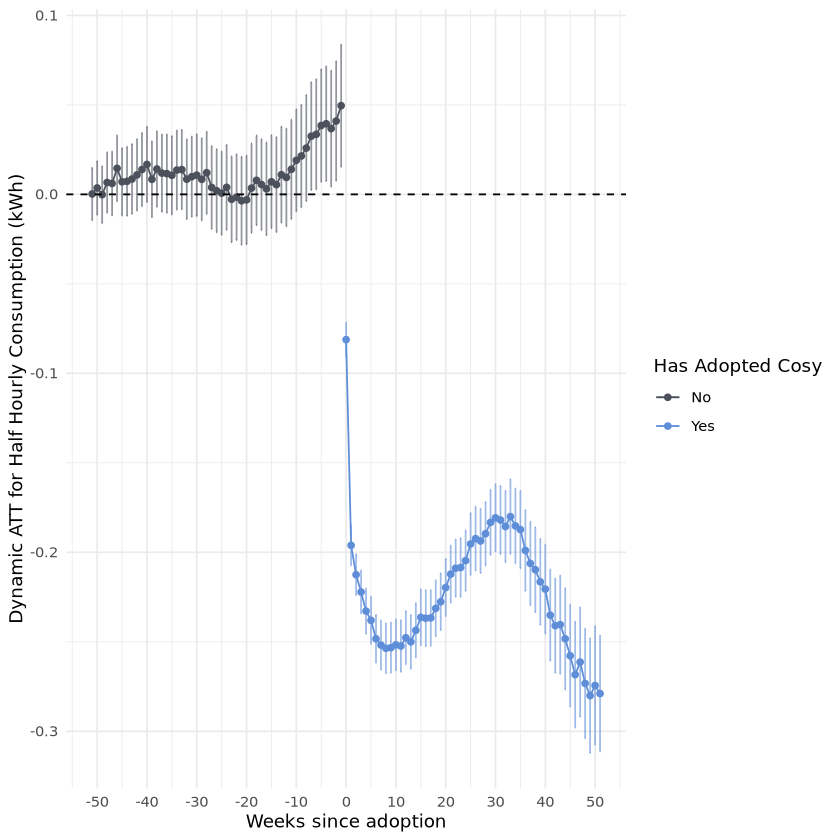

[1] "Creating plot for Afternoon Cosy"


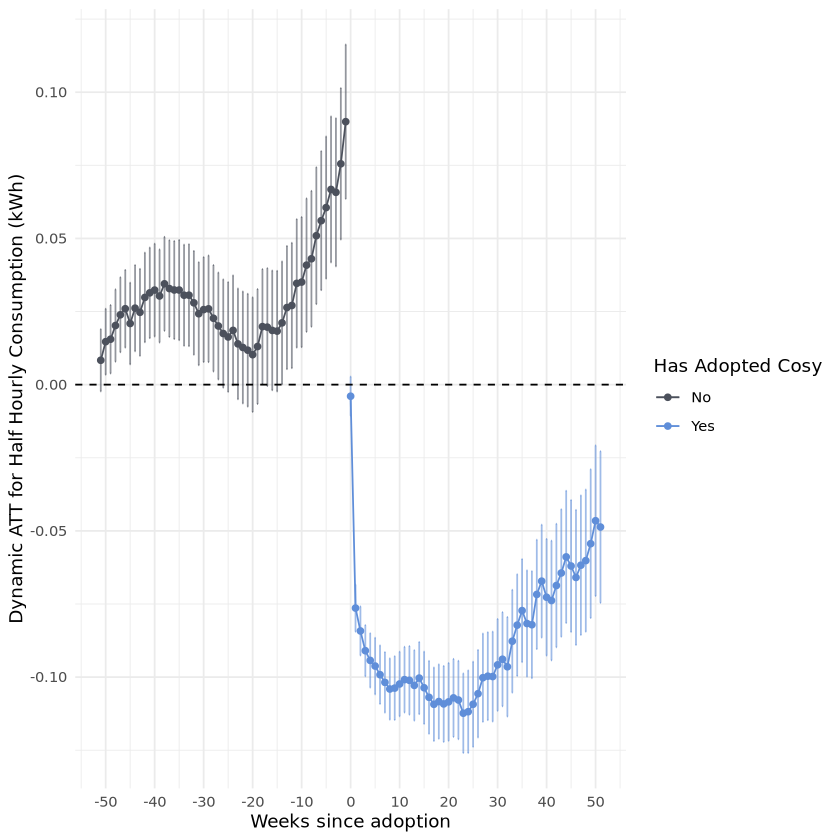

[1] "Creating plot for Morning Cosy"


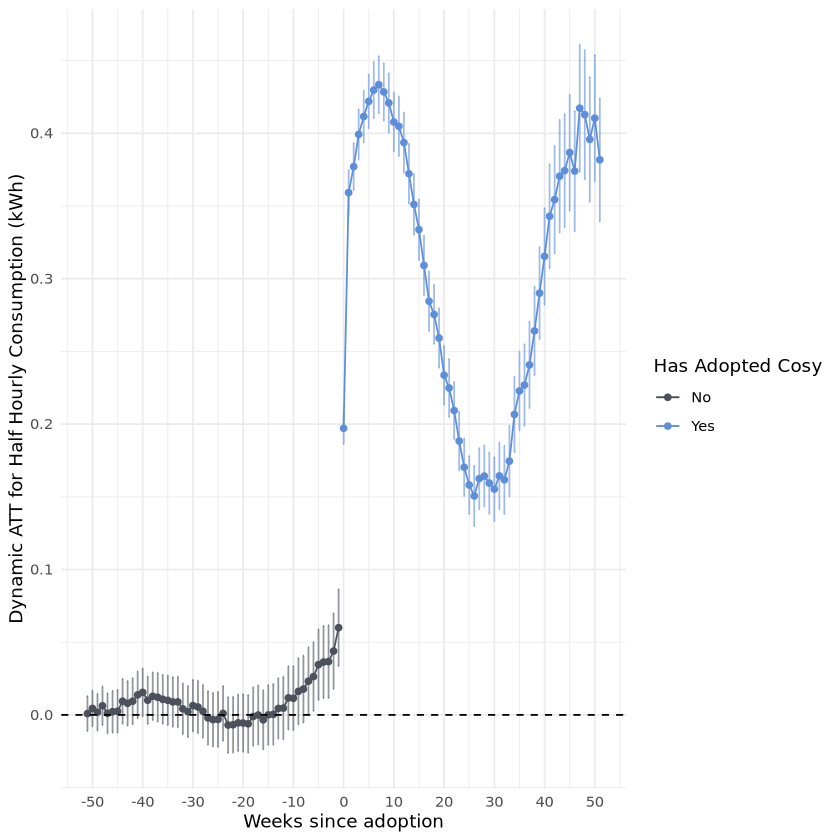

[1] "Creating plot for Overall"


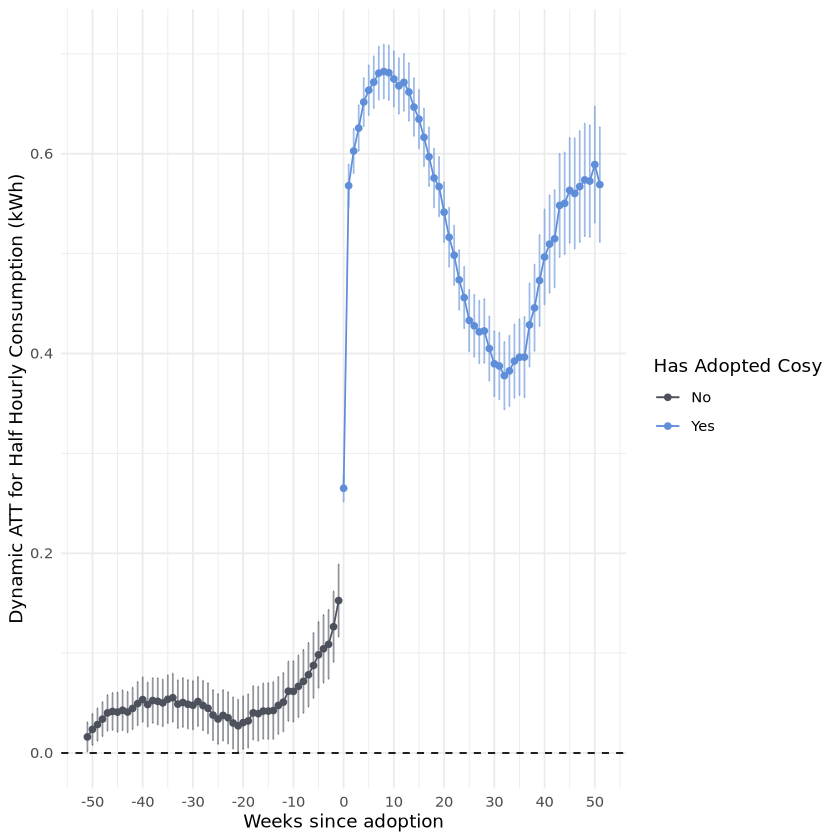

     lhs                term            coefficient           std.error       
 Length:515         Length:515         Min.   :-0.2801055   Min.   :0.003099  
 Class :character   Class :character   1st Qu.:-0.0001197   1st Qu.:0.008119  
 Mode  :character   Mode  :character   Median : 0.0236513   Median :0.010242  
                                       Mean   : 0.0695587   Mean   :0.010977  
                                       3rd Qu.: 0.0613088   3rd Qu.:0.012784  
                                       Max.   : 0.6823557   Max.   :0.029704  
    conf.low           conf.high          event_time     lower_ci        
 Min.   :-0.312166   Min.   :-0.24805   Min.   :-51   Min.   :-0.312166  
 1st Qu.:-0.019240   1st Qu.: 0.01687   1st Qu.:-26   1st Qu.:-0.019240  
 Median : 0.004984   Median : 0.04090   Median :  0   Median : 0.004984  
 Mean   : 0.048044   Mean   : 0.09107   Mean   :  0   Mean   : 0.048044  
 3rd Qu.: 0.045451   3rd Qu.: 0.08556   3rd Qu.: 26   3rd Qu.: 0.045451  
 Ma

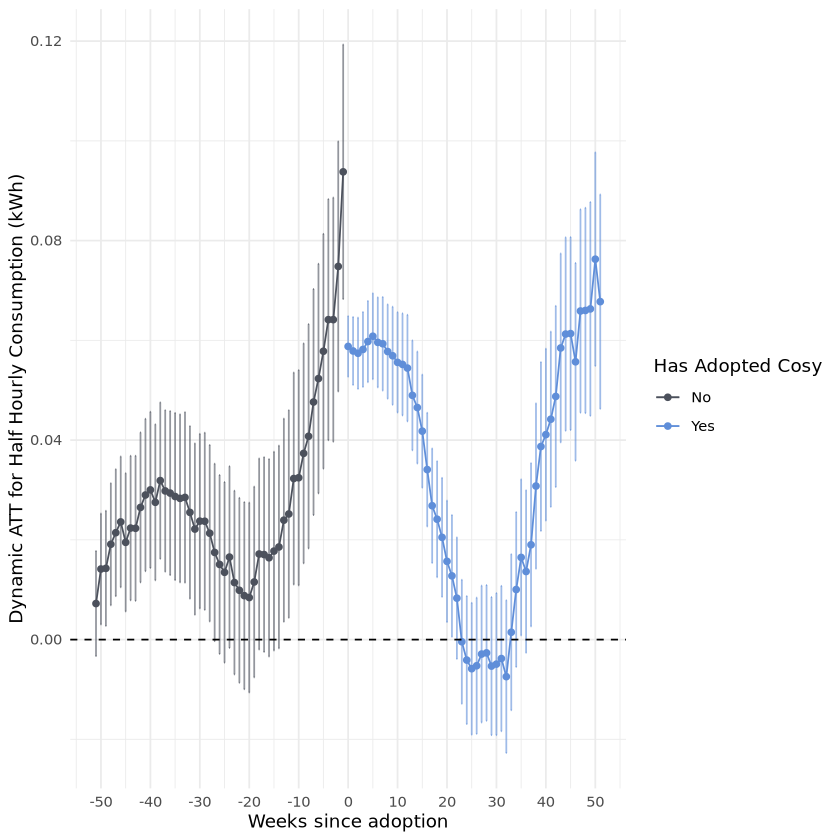

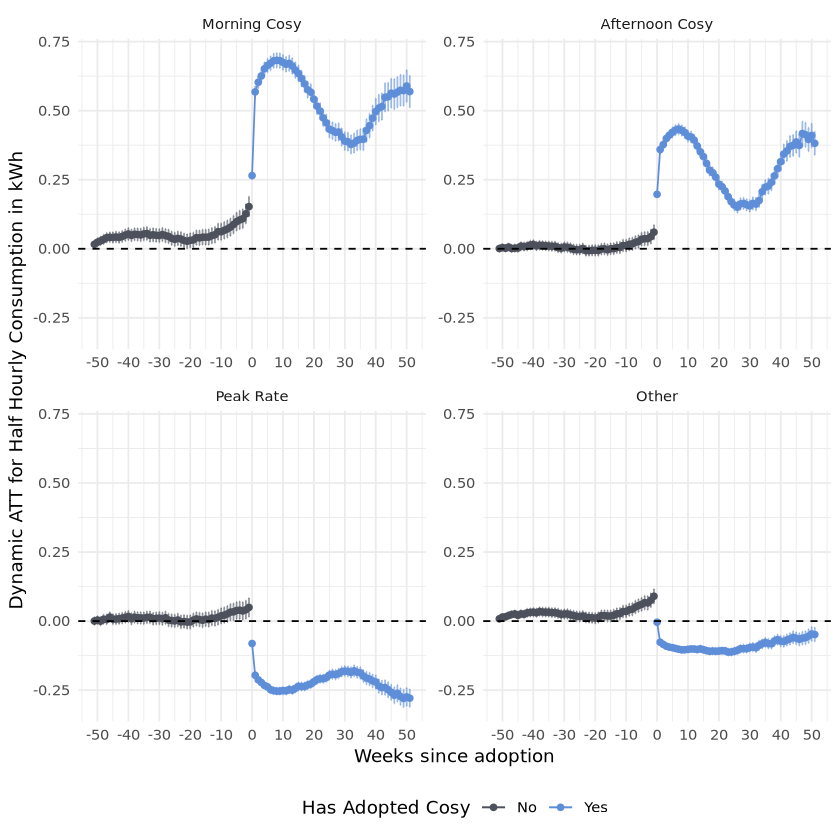

In [49]:
library(ggplot2)
library(dplyr)

# Initialize an empty data frame to store all period data
all_period_data <- data.frame()

# Loop through each period in the list and create/save the plots
for(i in seq_along(imputation_results_list)) {
  
  # Get the name of the period
  period_name <- gsub("period_", "", names(imputation_results_list)[i])
  print(paste0("Creating plot for ", period_name)) 
    
  # Get the imputation result for this period
  period_data <- imputation_results_list[[i]] %>% 
                rename(coefficient = estimate) %>%
                mutate(event_time = as.numeric(term)) %>%
                filter(event_time > -52, event_time < 52) %>%
                mutate(lower_ci =  conf.low,
                       upper_ci =  conf.high,
                       period = factor(ifelse(event_time < 0, "No", "Yes"), levels = c("Yes", "No")),
                       cosy_status = ifelse(event_time < 0, "No", "Yes"),
                       period = factor(period_name, levels = c("Morning Cosy",
                                            "Afternoon Cosy",
                                            "Peak Rate",
                                            "Other", 
                                            "Overall")))
                       
  

  
  # Create the plot
  p <- ggplot(period_data, aes(x = event_time, y = coefficient, color = cosy_status)) +
    geom_point() +
    geom_line() +
    geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
    scale_color_manual(
      name = "Has Adopted Cosy", 
      labels = c("No" = "No", "Yes" = "Yes"),
      values = c("No" = flexible_color, "Yes" = cosy_color)  # Custom colors
    ) +
    scale_x_continuous(breaks = seq(-50, 50, 10)) +
    labs(
      x = "Weeks since adoption",
      y = "Dynamic ATT for Half Hourly Consumption (kWh)"
    ) +
    theme_minimal()
  
  # Print the plot
  print(p)
  
  # Define the filename
  file_name <- paste("../graphs/imputation_plot_", period_name, ".png", sep = "")
  
  # Save the plot
  ggsave(file_name, plot = p, device = "png", width = 10, height = 8, dpi = 300)

  # Combine the data
  all_period_data <- bind_rows(all_period_data, period_data)
}

# Check summary of combined data
summary(all_period_data)

# Define global y-axis limits
y_min <- min(all_period_data$lower_ci, na.rm = TRUE)
y_max <- max(all_period_data$upper_ci, na.rm = TRUE)

# Create the ggplot for all periods using facet_wrap
ggplot(all_period_data %>% filter(!period == "Overall"), aes(x = event_time, y = coefficient, color = cosy_status)) +
  geom_point() +
  geom_line() +
  geom_errorbar(aes(ymin = lower_ci, ymax = upper_ci), width = 0.2, alpha = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Add horizontal line at y = 0
  scale_color_manual(
    name = "Has Adopted Cosy", 
    labels = c("No" = "No", "Yes" = "Yes"),
    values = c("No" = flexible_color, "Yes" = cosy_color)  # Adjust these colors as needed
  ) +
  scale_x_continuous(breaks = scales::pretty_breaks(n = 10)) +
  scale_y_continuous(limits = c(y_min, y_max)) +  # Set consistent y-axis range
  labs(
    x = "Weeks since adoption",
    y = "Dynamic ATT for Half Hourly Consumption in kWh"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom") +
  facet_wrap(~ period, scales = "free")

# Save the combined plot
ggsave("../graphs/dynamic_att_combined_imputation.png", device = "png", width = 16, height = 12, dpi = 300)